In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import json
from scipy.stats import poisson
import matplotlib.pyplot as plt

import torch

import datetime

import activityscope_utils as utils
import os
import tempfile

In [ ]:
## MOST IMPORTANT PARAMETER TO SET: do you want the paper's reproducibility snapshot of the data,
## or do you want the latest data?
use_reproducibility_snapshot = False  # If True, will use a reproducibility snapshot of the data. If False, will use the latest data.

In [3]:
# PARAMETERS

# We are doing >= 4 opps as the positive class in the binary classification example
NUM_OPPS_FOR_TRAINING = 4

# Training filters (less than this and we don't trust the orbit)
MIN_ARC_LENGTH_FOR_TRAINING = 20
MIN_NUM_OBS_FOR_TRAINING = 16

# Total training time limit (seconds), don't set below 500, but potentially go up to two hours for maximum performance
TRAINING_TIME_LIMIT = 4000

# Load known active objects and dual designation list from JSON files
# This is NOT used in any way to bias the model results, and if you remove it, the model will still behave overall in roughly the same way.
# Excluding them may improve model performance by reducing noise in the training data, and may allow the next layer of discoveries to emerge more clearly.
with open('known_active_objects.json', 'r') as f:
    known_strongly_suspected_active_objects = json.load(f)

# MPC lists these as (2060) for example and pandas makes that a negative number. We are removing dual asteroid comet designations from the training set.
with open('dual_designation_list.json', 'r') as f:
    dual_designation_list = json.load(f)

# Processing Part 1. Data Loading, Filtering & Feature Engineering



The `utils.load_all_databases()` function performs comprehensive database loading and initial processing.

**Database Loading:**

- Loads MPC (Minor Planet Center) orbit database from `mpcorb_extended.json.gz

- Creates `Is_Past_Threshold` binary classification target (>= 4 oppositions). Creates `Num_opps_minus_one` regression target (additional oppositions beyond the first) which is the regression target.

- Loads astrometry counts from local JSON file and merges with MPC data. These astrometry counts can be generated using the astrometry_counter.ipynb notebook.

- Loads AstDyS multi-opposition and single-opposition catalogs

- Loads JPL (Jet Propulsion Laboratory) unnumbered objects database

- `filter out unless updated.csv` - objects excluded unless orbit has been updated (arc length changed)

- `filter until further notice.csv` - objects excluded until removed from the file

**Database Cross-Comparison:**

- Applies filter lists to exclude problematic objects:

- Compares MPC orbits with AstDyS to identify multi-opposition discrepancies- Applies magnitude corrections from `absolute magnitude fixes.csv` for objects with known photometry issues

- Compares MPC orbits with JPL for independent verification

**Data Quality Corrections:**

- Computes absolute differences in orbital elements (H magnitude, semi-major axis a, eccentricity e, inclination i) between MPC and AstDyS

- Computes H magnitude differences with JPL- Sets final H magnitude to the **dimmest** (most conservative) value across all three databases


The `utils.feature_engineering()` function then adds **visibility metrics** (apparent magnitudes at various orbital configurations), **orbital dynamics features** (Tisserand parameter, resonances, Trojan classification), and **geometric features** (perihelion direction vectors, declination, galactic plane alignment).

In [ ]:
if use_reproducibility_snapshot:
    # Load the reproducibility snapshot of the database from a parquet file
    orb = pd.read_parquet('orb_snapshot.parquet')
else:
    try:
        orb = utils.load_all_databases()
    except Exception as e:
        print(f"Error loading databases: {e}")
        # delete all from .cache folder so that next time it might work
        cache_dir = os.path.join(os.getcwd(), '.cache')
        # delete all files from the cache directory
        for filename in os.listdir(cache_dir):
            file_path = os.path.join(cache_dir, filename)
            try:
                if os.path.isfile(file_path):
                    os.unlink(file_path)
            except Exception as e:
                print(f"Error deleting file {file_path}: {e}")

        raise Exception(f"Failed to load databases. To fix this, try deleting all files in the cache directory: {cache_dir}. Original error: {e}")

# Un-comment this if wishing to make a new shapshot of the database
# orb.to_parquet('orb_snapshot.parquet', compression='zstd', index=False)

# The default (lean) feature set computes everything in mlcols below. The exploratory /
# superseded families (vis_opp_*, the last-perihelia columns) are skipped; pass
# extra_features=True to get them back, byte for byte unchanged.
orb = utils.feature_engineering(orb)

# Filtering of Training Dataset

After database loading and feature engineering, we apply additional filters to create a high-quality training set. These filters ensure the training data consists of well-observed, reliably linked objects with concordant orbital elements across independent databases.

**Extension Difficulty Filter:**

- Merges pre-computed `extension_difficulty` metric (probability an orbit linkage is incorrect)

- We re-calculate extension difficulty later but this is a pre-stored one used only for filtering the training dataset

**Training Set Quality Filters (applied below):**

- See pandas code for exact filters

In [5]:
# This is prior saved extension difficulty which we'll use for filtering purposes up front. We can re-estimate these right after the modeling is done.
extension_difficulty = pd.read_csv("extension_difficulty.csv")
orb = orb.merge(extension_difficulty, on="Principal_desig", how="left")

In [6]:
# A variety of filters to select decent quality orbits for training. We want as few as possible poorly defined orbits and mislinkages in the training database.
# In some ways less is more at this stage so that the model is not confused by noisy data.

orb_decent_orbit = orb[((orb["Arc_length"]>=MIN_ARC_LENGTH_FOR_TRAINING)|(orb["Arc_length"].isna())|(orb["Perihelion_dist"]<1.3)) # allow more NEOs into the training set to boost performance on these
                       &(orb["Num_obs"]>=MIN_NUM_OBS_FOR_TRAINING)
                       &~orb["filtered_out"].astype(bool)
                       # the following 5 filters are to further filter out situations of disagreement between MPC and AstDyS and JPL
                       &(orb["a_diff_abs"]<0.0005)
                       &(orb["e_diff_abs"]<0.00015)
                       &(orb["i_diff_abs"]<0.003)
                       &(orb["multi_opp_disagree"]==0)
                       &((orb["extension_difficulty"]<0.1)| (orb["extension_difficulty"].isna())|(orb["Perihelion_dist"]<1.3)) # allow more NEOs into the training set to boost performance on these, also few mislinkages for these
                       # Use MPC U parameter as another filter
                       &((orb["U"]<9)|(orb["Perihelion_dist"]<1.3)) # allow more NEOs into training
                       # We will not train on known active objects as the model is supposed to reflect the inert asteroid population
                       &~orb["Principal_desig"].isin(known_strongly_suspected_active_objects)
                       &~orb["Number"].isin(dual_designation_list)]

print(f"Total objects in orbit database: {len(orb)}")
print(f"Total objects in decent orbit database: {len(orb_decent_orbit)}")

orb_training = orb_decent_orbit


Total objects in orbit database: 1561163
Total objects in decent orbit database: 1374711


# Processing Part 2. Model Training
There are two models: Poisson regression followed by binary classification where the latter model is alloed to reference the out-of-fold predictions by the former.

In [7]:
## FEATURES TO USE (arrived at by feature selection)
# Keep this list identical to the one in
# "More Complicated Workbook - including paper-specific items.ipynb" and to the 12
# features described in the paper (Section: Model Features).
mlcols = ['H', 'Node', 'a', 'i', 'vis_q',
          'Perihelion_direction_x_e', 'Perihelion_direction_y_e',
          'days_since_last_opp',
          'n_detectable', 'n_detectable_var', 'years_since_first_detectable', 'days_since_last_detectable',
       'Is_Past_Threshold']

print(f"Number of features used for classification: {len(mlcols) - 1}")

# for the regression model, swap "Is_Past_Threshold" with "Num_opps" in the feature list
mlcols_reg = mlcols.copy()
mlcols_reg.remove("Is_Past_Threshold")
mlcols_reg.append("Num_opps_minus_one")

data_df = orb_training.dropna(subset=["H"])[mlcols].astype(np.float32)
data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg].astype(np.float32)

# Shared 8-fold assignment so the regression, quantile, and binary predictors use identical splits.
# This eliminates leakage of exp_Num_opps / quantile_Opps OOF features into the binary classifier:
# when fold k is held out for the classifier, the regression OOF predictions on the training folds
# were produced by regressors that also never saw fold k. AutoGluon's groups= auto-excludes this column.
shared_folds = np.random.default_rng(0).integers(0, 8, size=len(data_df))
data_df["Shared_Fold"] = shared_folds
data_df_reg["Shared_Fold"] = shared_folds

# so we don't try to save the heavy models forever since each is intended to be ephemeral for a single run
save_path = os.path.join(tempfile.gettempdir(), 'activityscope_ag')

Number of features used for classification: 14


In [9]:
# KEY TO REGRESSION: We see the first opposition as a given. No object ends up in any orbit database with zero oppositions.
# Then each additional opposition is an approximately Poisson process dependent on visibility factors.
# Poisson assumptions are indeed violated somewhat (survey depth not constant forever in time/history) but this is still likely the best model to use—
# except possibly Tweedie regression which we will evaluate in future work.


# Regression model training
predictor_reg = TabularPredictor(label="Num_opps_minus_one", groups="Shared_Fold", eval_metric=utils.POISSON_SCORER, problem_type='regression', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_reg.fit(data_df_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_POISSON, num_stack_levels=0, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["exp_Num_opps"] = predictor_reg.predict(data_df) + 1


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.03 GB / 32.00 GB (18.8%)
Disk Space Avail:   16.41 GB / 926.35 GB (1.8%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in co

[1000]	valid_set's poisson: -13.2349	valid_set's mean_poisson_deviance: -0.415355
[1000]	valid_set's poisson: -13.1468	valid_set's mean_poisson_deviance: -0.419237
[1000]	valid_set's poisson: -13.1809	valid_set's mean_poisson_deviance: -0.416549
[1000]	valid_set's poisson: -13.2184	valid_set's mean_poisson_deviance: -0.414708
[1000]	valid_set's poisson: -13.2136	valid_set's mean_poisson_deviance: -0.412172
[1000]	valid_set's poisson: -13.1818	valid_set's mean_poisson_deviance: -0.41829
[1000]	valid_set's poisson: -13.2464	valid_set's mean_poisson_deviance: -0.414531
[1000]	valid_set's poisson: -13.1591	valid_set's mean_poisson_deviance: -0.418901


	-0.4162	 = Validation score   (-mean_poisson_deviance)
	295.96s	 = Training   runtime
	12.61s	 = Validation runtime
Fitting model: XGBoost_BAG_L1 ... Training model for up to 1017.90s of the 1017.88s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.4146	 = Validation score   (-mean_poisson_deviance)
	871.56s	 = Training   runtime
	20.13s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 124.59s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=10, gpus=0, mem=0.1/7.1 GB
	Ensemble Weights: {'XGBoost_BAG_L1': 0.636, 'LightGBM_BAG_L1': 0.364}
	-0.4138	 = Validation score   (-mean_poisson_deviance)
	0.93s	 = Training   runtime
	0.02s	 = Validation runtime
AutoGluon training complete, total runtime = 1210.22s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 5249.4 rows/s (171839 batch size)
Automatically perfor

In [10]:
data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
# Also expose the regression OOF predictions to the quantile model as a feature.
# Safe under shared folds: for any held-out fold k, the exp_Num_opps values on fold k
# were generated by reg models that excluded fold k, so no label leaks into quant's validation.
data_df_reg["exp_Num_opps"] = data_df["exp_Num_opps"]
# data_df["poisson_cdf_lte4"] = poisson.cdf(4-1, data_df["exp_Num_opps"]-1)

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_84030/2806720809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)


In [11]:
# Quantile regression

# Regression model training
predictor_quant = TabularPredictor(label="Num_opps_minus_one", groups="Shared_Fold", problem_type='quantile', quantile_levels=[0.006], path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_quant.fit(data_df_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_QUANTILE, num_stack_levels=1, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       7.29 GB / 32.00 GB (22.8%)
Disk Space Avail:   15.92 GB / 926.35 GB (1.7%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in co

In [12]:

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["quantile_Opps"] = predictor_quant.predict(data_df)[0.006] + 1
data_df["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)

Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_84030/1045314886.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)


In [13]:
# Binary Classifier Training

# There's a known issue where torch probability calibration dies sometimes with multiple threads. This is a workaround.
torch.set_num_threads(1)

predictor = TabularPredictor(label="Is_Past_Threshold", groups="Shared_Fold", eval_metric='log_loss', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor.fit(data_df, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_BINARY, num_stack_levels=0, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.44 GB / 32.00 GB (20.1%)
Disk Space Avail:   15.58 GB / 926.35 GB (1.7%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in co

# Processing Part 3. Make Predictions for Every Asteroid
The two key predictions are exp_Num_opps and prob from the two models.
Note that the out-of-fold predictions are used for anything that was included in training data.

In [14]:
# Hard code both 2009 DP2 and 2024 XE22 to Num_opps = 1 with Arc_length of 22 for illustration purposes
# this is so that we can clearly show what the scores were WHEN THE MODEL FLAGGED THEM as single-opp comets
orb.loc[orb["Principal_desig"]=="2009 DP2", "Num_opps"] = 1
orb.loc[orb["Principal_desig"]=="2024 XE22", "Num_opps"] = 1
orb.loc[orb["Principal_desig"]=="2009 DP2", "Arc_length"] = 22 # dummy length of an "immanently extensible" arc
orb.loc[orb["Principal_desig"]=="2024 XE22", "Arc_length"] = 22 # dummy length of an "immanently extensible" arc

In [15]:
# No absolute magnitude means fundamentally impossible to apply these methods
orb_pred = orb.dropna(subset=["H_MPC","H_astdys","H_jpl"], how='all').copy()

#these
orb_pred = utils.apply_nights_overrides(orb_pred)
orb_pred = utils.apply_magnitude_corrections(orb_pred)

# Now the predictions for the regression model
orb_pred["exp_Num_opps"] = predictor_reg.predict(orb_pred) + 1
orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)

orb_pred["quantile_Opps"] = predictor_quant.predict(orb_pred)[0.006] + 1
orb_pred["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)

# Predictions for the probabalistic binary classification model
# predict_proba to set probs in orb_pred (this sets the probability for anything not in the training dataset, but anything in the training will get overridden in the next line)
orb_pred["prob"] = predictor.predict_proba(orb_pred)[1]
# override the prob field in orb_pred to ag_probs lining up data index, but only for the rows that exist in both (same index in both)
orb_pred["prob"].update(TabularPredictor.predict_proba_oof(predictor)[1])

orb_pred["poisson_cdf"] = poisson.cdf(orb_pred["Num_opps"]-1, orb_pred["exp_Num_opps"]-1)

# Renames a few columns and adds DeltaQ column
final = utils.getFinal(orb_pred,known_strongly_suspected_active_objects)

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_84030/274458148.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_84030/274458148.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series thr

# Processing Part 4. Extension Difficulty Classifier


The `extension_difficulty` feature quantifies how challenging it is to extend an object's orbit, capturing two distinct situations which would make it difficult or impossible to recover/extend using the ITF. In the case of mislinkage, recovery/extension is impossible as the object does not exist and the orbit is nonsense. In the case of orbital uncertainty too high to recover the object, it may be possible to recover in the ITF but difficult because of the sheer number of plausible tracklets that might match it.

This classifier uses the principle that highly-rated objects from the prior ML models that remain single opposition are more representative of "difficult to extend" objects. The extension difficulty is based primarily on astrometry metadata (e.g., number of nights, arc length, gap patterns) rather than orbital elements themselves.

In [16]:
import importlib
importlib.reload(utils)

# Train extension difficulty classifier
orb_pred, final = utils.train_extension_difficulty_classifier(orb_pred, final, orb)

# filter out objects marked in either of the two named filter csvs
orb_pred_incl_mislinkages = orb_pred.copy()
orb_pred = orb_pred[~orb_pred["filtered_out"].astype(bool)]
final = final[~final["filtered_out"].astype(bool)]
orb_pred_incl_mislinkages = utils.getFinal(orb_pred_incl_mislinkages,known_strongly_suspected_active_objects)

Positive examples from filter list: 39
Positive examples from multi-opp mislinkages: 95
Positive examples (high extension difficulty): 1644
Negative examples (low extension difficulty): 482640
Training set after refinement: 483553


In [17]:
# # Uncomment this section if you want to update the pre-baked extension_difficulty.csv which is used for TRAINING filtering only
# orb_pred[["Principal_desig", "extension_difficulty"]].to_csv("extension_difficulty.csv", index=False)

# Results Part 1: Centralized Ranking using DeltaQ and extension_difficulty, with comet backup tables

Remember that all predictions here are out-of-fold predictions, that is each prediction is made using training data that excludes itself.
This is possible because AutoGluon uses cross validation and we are using the predict_proba_oof method for data in the training dataset.

Using priority_score is the best practical unified system for identifying active objects. That said, it is not as rigorously defined or as fully researched as the ActivitySCOPE anomaly scores. See this primarily as a convenience tool to rank as many active objects as possible all in one place, but we also include lists not sorting by priority_score as well given that they require slightly less trust in a somewhat experimental system.

**NOTICE THE (almost) LINEAR SEPARABILITY OF THIS RANKING SYSTEM**

As of June 2026, this typically ranks 2025 HV38 as the highest-anomaly object and 2002 CW116 as the lowest-anomaly of the known/suspected active objects by our methods. Typically only 0-2 objects will intervene such that 16 of the top 18 ranked here are always known active objects. Anything interjecting itself in this list above 2002 CW116 is VERY worthwhile to investigate and is clearly above the survey completeness floor. It should generally be extensible, linkable to another object designation, if appearing in this list above 2002 CW116.

In [18]:
default_col_set = ["prob", "DeltaQ", "poisson_cdf", "extension_difficulty", "Num_opps", "quantile_Opps", "exp_Num_opps", "nights_total",  "Ref", "Num_obs", "Arc_length", "U","a","i","H","q","TJ"]

# engineer a feature that grades overall "priority" of follow up based on a gradient such that up and to the left on the scatterplot below is higher priority and lines of equal priority are parallel
final["priority_score"] = final["DeltaQ"] - (final["extension_difficulty"] * 15.5)

combined_rankings = final[((final["Arc_length"]>=8)|(final["Arc_length"].isna()))
      &(final["Num_obs"]>=6)

      # Admitted this is a bit of a hack but it excludes THOR objects which sometimes still trip up the extension_difficulty classifier
      &((final["Num_obs"]>=7)|(final["nights_total"]>=5))

      # This is necessary because some very observable objects will be slightly on the low end but still get a high DeltaQ. Perhaps in future versions of this we replace DeltaQ with
      # a metric that is relative to Q_0.006 instead of just subtraction
      &(final["DeltaQ"]>0.3*final["quantile_Opps"])

      &(final["prob"]>0.9)
      &(final["q"]>1.1)
      &(final["Orbital_period"]<20)].copy()

combined_rankings.sort_values("priority_score", ascending=False, inplace=True)

combined_rankings.head(1000)[['Known / Strong Suspect']+default_col_set].head(25)

,Known / Strong Suspect,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,
2025 HV38,True,0.999995,16.651649,2.386943e-09,0.000001,1,17.651649,20.853252,18.0,MPO988024,48,51,8,2.484172,7.24007,15.42,2.366069,3.463847
2008 BJ22,True,0.999994,15.13884,7.757540e-09,0.000023,1,16.138840,19.674601,13.0,MPO732621,53,83,4,3.073201,11.51245,15.20,2.942906,3.197832
2008 GO98,True,0.999993,13.927719,1.117692e-05,0.000190,7,20.927719,25.212576,NaN,MPO969452,1549,<NA>,0,3.971173,15.55983,12.91,2.864301,2.92673
2019 OE31,True,0.999992,12.247834,7.791442e-08,0.000814,1,13.247834,17.367655,10.0,E2024-JA9,32,137,3,4.381322,5.22115,14.64,3.942522,3.006031
2010 RH69,True,0.999993,12.022973,3.874290e-06,0.000194,3,15.022973,18.619276,11.0,MPO619842,31,<NA>,5,4.532396,11.54822,13.95,4.276048,2.97391
2003 BM80,True,0.999995,11.382689,1.366922e-04,0.000190,7,18.382689,21.862354,NaN,MPO984040,222,<NA>,0,4.234372,5.81319,13.62,3.438718,2.991756
2001 BV70,True,0.999994,11.019577,3.957938e-07,0.000123,1,12.019577,15.742373,8.0,MPO 13809,32,50,10,3.593632,4.33032,15.14,2.063079,2.947403
2007 VB146,True,0.999992,10.019155,9.027183e-07,0.001203,1,11.019155,14.917855,4.0,MPO130330,13,16,10,2.752892,3.49271,16.94,2.439879,3.332674
2015 BC566,True,0.999991,8.927389,3.146386e-06,0.000003,1,9.927389,13.669256,11.0,MPO771428,52,39,5,3.06321,11.68986,16.33,2.951045,3.200295


In [19]:
# A list of more uncertain ones to try if time allows. Addition of a single archival night could push it into very low extension_difficulty and high confidence candidate territory.
uncertain_rankings = final[((final["Arc_length"]>=8)|(final["Arc_length"].isna()))
      &(final["Num_obs"]>=6)

      # Admitted this is a bit of a hack but it excludes THOR objects which sometimes still trip up the extension_difficulty classifier
      &((final["Num_obs"]>=7)|(final["nights_total"]>=5))

      # This is necessary because some very observable objects will be slightly on the low end but still get a high DeltaQ. Perhaps in future versions of this we replace DeltaQ with
      # a metric that is relative to Q_0.006 instead of just subtraction
      &(final["DeltaQ"]>0.3*final["quantile_Opps"])

      &((final["U"].between(8,9))| (final["Arc_length"]<13))

      &(final["prob"]>0.9)
      &(final["q"]>1.1)
      &(final["Orbital_period"]<20)].copy()

uncertain_rankings.sort_values("priority_score", ascending=False, inplace=True)

uncertain_rankings.head(1000)[['Known / Strong Suspect']+default_col_set].head(25)

,Known / Strong Suspect,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,
2025 HV38,True,0.999995,16.651649,2.386943e-09,0.000001,1,17.651649,20.853252,18.0,MPO988024,48,51,8,2.484172,7.24007,15.42,2.366069,3.463847
2025 NV385,False,0.999879,4.024612,2.441953e-04,0.002401,1,5.024612,9.317542,4.0,E2026-L57,8,8,9,2.368791,7.47077,18.04,1.934285,3.511802
2022 UH55,False,0.997536,3.092544,4.514892e-04,0.009610,1,4.092544,8.702959,4.0,MPO719018,13,14,9,3.122898,10.52362,17.07,2.903454,3.185718
2001 UY217,False,0.996513,2.830685,1.233046e-03,0.000620,1,3.830685,7.698268,4.0,MPO285656,13,9,10,2.107378,2.67958,19.09,1.719158,3.718634
2001 FL205,False,0.991767,2.671621,1.906532e-03,0.000932,1,3.671621,7.262469,4.0,MPO346179,13,10,10,3.034927,16.9253,16.80,2.288811,3.130848
2025 LF5,False,0.995603,2.588123,8.775641e-04,0.003462,1,3.588123,8.038361,4.0,E2026-L27,18,54,8,2.535539,1.23479,18.44,2.438243,3.446847
2025 QB175,False,0.999368,3.583843,5.025988e-04,0.070096,1,4.583843,8.595718,3.0,E2026-HE1,8,11,9,2.734152,0.38037,18.07,2.268057,3.331534
2024 TR15,False,0.993540,2.474058,8.040503e-04,0.000160,1,3.474058,8.125849,4.0,MPO873056,13,10,6,3.036671,9.13842,17.27,2.828388,3.218368
2025 OZ131,False,0.994614,2.430165,2.586290e-03,0.001097,1,3.430165,6.957531,4.0,MPO978819,12,10,9,3.224189,10.12368,17.12,2.450434,3.118328


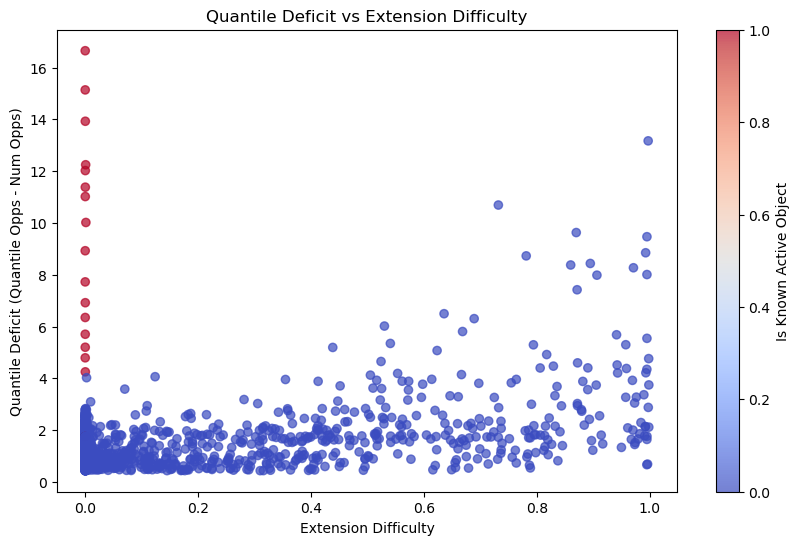

In [20]:
# plot DeltaQ vs extension difficulty, RED is known active object, BLUE is not so listed in the known active json
temp_for_plot = combined_rankings[combined_rankings["DeltaQ"]>0]
plt.figure(figsize=(10,6))
plt.scatter(temp_for_plot["extension_difficulty"], temp_for_plot["DeltaQ"], c=temp_for_plot["Known / Strong Suspect"], cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Is Known Active Object')
plt.xlabel('Extension Difficulty')
plt.ylabel('Quantile Deficit (Quantile Opps - Num Opps)')
plt.title('Quantile Deficit vs Extension Difficulty')
plt.show()

In [21]:
# Semi major axis a > 5.4 list, since we find that objects like 2024 XE22, 2009 DP2, and 2008 VK110 may not appear in the above list.
final[((final["Arc_length"]>=8)|(final["Arc_length"].isna()))
      &(final["Num_obs"]>=6)
      &(final["a"]>5.4)

      &(final["Num_opps"]<9)
      &(final["prob"]>0.65)
      
      &((final["extension_difficulty"].between(0,0.5))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)].sort_values("poisson_cdf", ascending=True).head(20)[default_col_set]

,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,
2024 XE22,0.989217,1.749841,0.001819,0.000068,1,2.749841,7.309677,10.0,MPO988022,36,22,4,5.86508,27.16003,14.26,4.535879,2.727256
2009 DP2,0.863065,0.407126,0.010112,0.000059,1,1.407126,5.594028,19.0,E2026-N01,79,22,2,6.646579,26.76899,14.17,3.822559,2.609808
2025 NX200,0.772716,-0.13445,0.028409,0.308996,1,0.865550,4.561033,3.0,MPO978588,6,20,9,6.469853,8.2019,14.47,4.891108,2.944885
2016 PW84,0.951016,-0.827114,0.096342,0.000021,3,2.172886,6.376119,13.0,MPO544895,49,<NA>,1,5.823954,14.52161,14.60,4.196552,2.860166
2008 VK110,0.887191,-1.602175,0.105981,0.000310,3,1.397825,6.238060,9.0,MPO791125,24,<NA>,4,7.167172,7.38588,14.06,4.436583,2.878252
2009 UN197,0.690281,-1.00504,0.197324,0.000610,2,0.994960,4.012266,11.0,E2026-QA9,50,<NA>,2,6.440449,4.67294,15.51,3.377159,2.758705
2020 XV1,0.911350,-2.486167,0.303742,0.000030,4,1.513833,5.738013,51.0,MPO725010,130,<NA>,0,5.928974,6.98953,14.88,3.553615,2.819162
2005 WY3,0.986156,-5.267186,0.355348,0.000190,8,2.732814,9.738902,NaN,E2026-P26,1377,<NA>,0,6.817115,29.33209,13.33,1.802311,2.115173
2010 KG12,0.984636,-3.431905,0.359264,0.000029,6,2.568095,7.567791,23.0,E2026-P69,90,<NA>,0,6.214001,23.05722,14.20,4.41843,2.7626


In [22]:
# A comet list: this is is required as some comets will be missed by DeltaQ ranking but found by poisson_cdf ranking

# Please note that 2009 DP2 has been hard-coded as H=14.2 (the brighter of it's two apparations)
# as the average of the two apparations would not flag it as clearly. It was flagged as a single-opp object with only the 2009 observations
# but its 2026 appartion leads to a calculated H_V of 16.0 (if we assumed it an inert asteroid)

comets = final[(final["Num_opps"]>=2)
      &(~final["a"].between(5,5.4))
      &(final["prob"]>.5)
      &(final["q"]>1.1)
      &(final["TJ"]<3.05)
      &(final["a"].between(1.1,9))
      &~(final["a"].between(4.9,5.5))
      &(final["poisson_cdf"]<0.05)
      &(final["DeltaQ"]>-4)
      &((final["extension_difficulty"].between(0,0.6)))
      &(final["Orbital_period"]<40)].copy()

comets.sort_values("poisson_cdf", ascending=True, inplace=True)
comets[['Known / Strong Suspect','TJ']+[c for c in default_col_set if c != 'TJ']].head(15)

,Known / Strong Suspect,TJ,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q
Principal_desig,,,,,,,,,,,,,,,,,,
2010 RH69,True,2.97391,0.999993,12.022973,0.000004,0.000194,3,15.022973,18.619276,11.0,MPO619842,31,<NA>,5,4.532396,11.54822,13.95,4.276048
2008 GO98,True,2.92673,0.999993,13.927719,0.000011,0.000190,7,20.927719,25.212576,NaN,MPO969452,1549,<NA>,0,3.971173,15.55983,12.91,2.864301
2003 BM80,True,2.991756,0.999995,11.382689,0.000137,0.000190,7,18.382689,21.862354,NaN,MPO984040,222,<NA>,0,4.234372,5.81319,13.62,3.438718
2017 QN84,True,2.943831,0.999993,5.70295,0.001983,0.000047,4,9.702950,13.187242,64.0,MPO907046,213,<NA>,0,3.769087,12.07147,14.97,2.474881
2012 TE365,False,3.017873,0.999055,1.281734,0.023218,0.000046,3,4.281734,8.321745,12.0,MPO600179,42,<NA>,1,3.985413,4.46211,16.20,3.217017
2019 GR44,False,3.022898,0.967310,0.814641,0.025938,0.000134,2,2.814641,6.528196,8.0,MPO687862,31,<NA>,2,3.167078,26.62581,16.70,2.70613
2018 LS24,False,3.026645,0.965935,0.856906,0.030987,0.000210,2,2.856906,6.317502,15.0,MPO600179,43,<NA>,2,3.121758,28.03877,16.80,2.797439
2013 TS210,False,3.026102,0.996308,0.826419,0.035710,0.000410,3,3.826419,7.751425,5.0,MPO600179,22,<NA>,3,3.570178,18.34323,16.30,3.322654
2022 SJ130,False,3.048829,0.960692,0.328856,0.038022,0.000213,2,2.328856,6.073531,11.0,MPO929959,37,<NA>,3,3.158139,24.94056,17.01,2.755387


# Results Part 2: Ranking Table Just with Filter then Sort
Remember that all predictions here are out-of-fold predictions, that is each prediction is made using training data that excludes itself.
This is possible because AutoGluon uses cross validation and we are using the predict_proba_oof method for data in the training dataset.

Since priority_score is experimental, below are the alternative filter-then-sort methods described in the paper

In [23]:
# Overall Single-Opposition List, broken out further below by orbital class
# You should still pay attention to extension_difficulty as anything above 0.01 means there are
# mitigating factors that make it more likely to be very difficult to recover in the ITF and/or a mislinkage
extension_difficulty_threshold = 0.07

cols_to_show = ["Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_opps"]==1)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.999)
      &(final["a"]>1.1)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.sort_values("prob", ascending=False).head(30)

,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2025 HV38,48,0.000001,17.651649,18.0,0.999995,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,20.853252
2008 BJ22,53,0.000023,16.138840,13.0,0.999994,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,19.674601
2001 BV70,32,0.000123,12.019577,8.0,0.999994,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,15.742373
2025 VZ8,50,0.000002,8.724609,15.0,0.999993,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,12.783778
2019 OE31,32,0.000814,13.247834,10.0,0.999992,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,17.367655
2007 VB146,13,0.001203,11.019155,4.0,0.999992,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,14.917855
2015 BC566,52,0.000003,9.927389,11.0,0.999991,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,13.669256
2009 FP8,22,0.000034,7.349651,7.0,0.999989,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,11.590043
2021 AY8,24,0.000137,7.920216,7.0,0.999988,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,11.942734


In [24]:
# Sort by DeltaQ instead of prob
tight_extension_difficulty_threshold = 0.002000

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.15,20)
      &final["extension_difficulty"].between(0,tight_extension_difficulty_threshold)]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(25)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,16.651649,48,0.000001,17.651649,18.0,0.999995,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999995,20.853252
2008 BJ22,15.13884,53,0.000023,16.138840,13.0,0.999994,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999994,19.674601
2008 GO98,13.927719,1549,0.000190,20.927719,NaN,0.999993,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999993,25.212576
2019 OE31,12.247834,32,0.000814,13.247834,10.0,0.999992,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999992,17.367655
2010 RH69,12.022973,31,0.000194,15.022973,11.0,0.999993,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999993,18.619276
2003 BM80,11.382689,222,0.000190,18.382689,NaN,0.999995,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999995,21.862354
2001 BV70,11.019577,32,0.000123,12.019577,8.0,0.999994,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999994,15.742373
2007 VB146,10.019155,13,0.001203,11.019155,4.0,0.999992,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999992,14.917855
2015 BC566,8.927389,52,0.000003,9.927389,11.0,0.999991,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999991,13.669256


In [25]:
# Sorting by extension_difficulty as a way to find out where the edge between typically good and typically inextensible values lies
cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &(final["DeltaQ"]>0.3*final["quantile_Opps"])
      &(final["q"]>1.1)
      &final["DeltaQ"].between(3.5,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(25)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,16.651649,48,0.000001,17.651649,18.0,0.999995,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999995,20.853252
2025 VZ8,7.724609,50,0.000002,8.724609,15.0,0.999993,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999993,12.783778
2015 BC566,8.927389,52,0.000003,9.927389,11.0,0.999991,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999991,13.669256
2018 BJ11,4.79223,46,0.000009,5.792230,13.0,0.999943,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999943,10.148591
2008 BJ22,15.13884,53,0.000023,16.138840,13.0,0.999994,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999994,19.674601
2009 FP8,6.349651,22,0.000034,7.349651,7.0,0.999989,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999989,11.590043
2017 QN84,5.70295,213,0.000047,9.702950,64.0,0.999993,MPO907046,<NA>,0,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999993,13.187242
2010 TR241,5.200169,12,0.000060,6.200169,4.0,0.999975,E2026-GD6,36,5,3.05075,0.099885,12.41983,16.97,2.746025,3.355474,3.193626,0.8,0.999975,10.109971
2001 BV70,11.019577,32,0.000123,12.019577,8.0,0.999994,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999994,15.742373


In [26]:
# Comets, Sorting by extension_difficulty
cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "Num_opps", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &~final["a"].between(4.9,5.5)
      &(final["TJ"]<3.05)
      &(final["Num_opps"]<=13)
      &final["prob"].between(0.85,1000)
      &final["DeltaQ"].between(2.8,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,Num_opps,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2018 BJ11,4.79223,46,0.000009,1,5.792230,13.0,0.999943,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999943,10.148591
2017 QN84,5.70295,213,0.000047,4,9.702950,64.0,0.999993,MPO907046,<NA>,0,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999993,13.187242
2001 BV70,11.019577,32,0.000123,1,12.019577,8.0,0.999994,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999994,15.742373
2008 GO98,13.927719,1549,0.000190,7,20.927719,NaN,0.999993,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999993,25.212576
2003 BM80,11.382689,222,0.000190,7,18.382689,NaN,0.999995,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999995,21.862354
2010 RH69,12.022973,31,0.000194,3,15.022973,11.0,0.999993,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999993,18.619276
2008 YB3,4.154292,533,0.000521,9,13.154292,NaN,0.999994,E2024-C06,<NA>,1,11.590737,0.439749,105.16413,9.46,6.493725,16.687748,-0.252411,0.59,0.999994,17.479454
2019 OE31,12.247834,32,0.000814,1,13.247834,10.0,0.999992,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999992,17.367655
2007 TD441,2.943506,7,0.109780,1,3.943506,3.0,0.997511,E2026-MB0,9,9,3.419821,0.427441,12.57225,16.33,1.958051,4.881591,2.952142,0.39,0.997511,7.595211


In [27]:
# Single-opposition asteroid-only list (T_J > 3.05), sorted by prob
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.07)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20).sort_values("prob", ascending=False)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999995,20.853252,0.000001
2008 BJ22,53,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999994,19.674601,0.000023
2025 VZ8,50,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999993,12.783778,0.000002
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999992,14.917855,0.001203
2015 BC566,52,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999991,13.669256,0.000003
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999989,11.590043,0.000034
2021 AY8,24,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999988,11.942734,0.000137
2010 TR241,12,E2026-GD6,36,5,3.05075,0.099885,12.41983,16.97,2.746025,3.355474,3.193626,0.8,0.999975,10.109971,0.000060
2002 CW116,27,E2024-D99,88,5,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999902,8.532773,0.000198


In [28]:
# 2025 and 2026 single-opposition list, sorted by prob
cols_to_show = ["Num_obs","extension_difficulty","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps"]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>5)
      &(final["prob"]>0.995)
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>=2025)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.to_clipboard()
tempout.head(10).sort_values("prob", ascending=False)

,Num_obs,extension_difficulty,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,0.000001,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999995,20.853252
2025 VZ8,50,0.000002,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999993,12.783778
2025 NC339,6,0.025885,E2026-J01,8,9,2.53305,0.028897,1.54719,18.19,2.459852,2.606249,3.448438,0.06,0.999902,10.421328
2025 NV385,8,0.002401,E2026-L57,8,9,2.368791,0.183429,7.47077,18.04,1.934285,2.803297,3.511802,0.05,0.999879,9.317542
2025 NX446,8,0.123818,E2026-L10,10,9,2.164547,0.098677,2.35596,18.95,1.950957,2.378137,3.686346,0.25,0.999694,9.218899
2025 NJ491,10,0.763653,E2026-L19,9,9,2.470514,0.048263,1.13196,18.34,2.351279,2.589749,3.482316,0.16,0.999579,9.554825
2025 QB175,8,0.070096,E2026-HE1,11,9,2.734152,0.170471,0.38037,18.07,2.268057,3.200248,3.331534,0.11,0.999368,8.595718
2025 OP522,6,0.063715,E2026-HE1,9,9,3.105579,0.226189,0.20401,17.52,2.40313,3.808028,3.18048,0.11,0.998741,8.262831
2025 RY15,10,0.660862,MPO950689,9,8,2.568844,0.118392,7.73927,17.89,2.264714,2.872973,3.40814,0.83,0.998511,8.509323


In [29]:
# JFC / Centaur Transition List (see https://arxiv.org/pdf/2512.11204)
cols_to_show = ["poisson_cdf", "extension_difficulty","Num_opps","Ref","Arc_length","U","a","e","i","H","q","TJ","prob", "exp_Num_opps"]
tempout = final[((final["Arc_length"]>11)| (final["Arc_length"].isna()))
      &(final["Num_obs"]>7)
      &(final["extension_difficulty"]<0.5)
      &(final["a"].between(4.05,5.05))
      &(final["TJ"]<3.05)
      &(final["prob"]>0.8)
      &(final["Orbital_period"]<20)].sort_values("poisson_cdf", ascending=True)
tempout = tempout[cols_to_show]
tempout.head(10)

,poisson_cdf,extension_difficulty,Num_opps,Ref,Arc_length,U,a,e,i,H,q,TJ,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,
2019 OE31,7.791442e-08,0.000814,1,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,3.006031,0.999992,17.367655
2010 RH69,3.874290e-06,0.000194,3,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,2.97391,0.999993,18.619276
2018 BJ11,1.063696e-04,0.000009,1,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,2.986205,0.999943,10.148591
2003 BM80,1.366922e-04,0.000190,7,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,2.991756,0.999995,21.862354
2015 WE43,8.742145e-04,0.363913,1,MPO885769,15,9,4.911482,0.059597,9.49885,15.02,4.618773,2.972469,0.992640,8.042185
2003 XN43,6.833851e-02,0.000022,4,MPO644189,<NA>,2,4.064148,0.245053,16.387,15.60,3.068217,2.924325,0.999870,8.278843
2000 EJ37,9.575080e-02,0.000190,11,MPO983854,<NA>,0,4.617423,0.705543,10.09302,13.71,1.359633,2.441353,0.999992,16.508926
2023 QP121,1.022596e-01,0.000027,6,MPO973353,<NA>,0,5.049485,0.03575,7.83338,14.82,4.868965,2.981043,0.999376,10.232940
2010 ES189,1.544417e-01,0.000099,3,MPO659990,<NA>,0,4.184707,0.348309,31.50244,15.60,2.727136,2.676863,0.891385,5.678814


# Import the Comet Orbit File from MPC
Beyond this point we aren't looking for new discoveries but mostly retrospectively looking at older discoveries.
We import the comet file only to get orbital elements etc. for prior discoveries so we can rank them for the paper (unfortunately didn't save the asteroidal MPCORB elements from prior to cometary confirmation)

In [ ]:
discoveries_in_comet_file = ["P/2025 UX109 (Ye)","P/2023 JN16 (Lemmon)","P/2022 BV9 (Lemmon)","P/2017 FL36 (PANSTARRS)","489P/Denning"]

# Objects moved to Comet Orbits (Archived Version, stored in repository since there are occasionally truncation issues live)
comet = pd.read_json("allcometels.json.gz",compression='gzip')

comet = comet[comet["Orbit_type"].isin(["P","D","A"])]
# comet = comet[comet["Designation_and_name"].str[0].isin(["P","D"])]

comet["a"] = comet["Perihelion_dist"] / (1 - comet["e"])
comet["Orbital_period"] = np.sqrt(comet["a"]**3)

comet["Tp"] = utils.calc_jd(comet["Year_of_perihelion"], comet["Month_of_perihelion"], comet["Day_of_perihelion"])
comet["Epoch"] = comet["Tp"]
comet["M"] = 0.0

# Only pulling in the magnitude data for comets from find_orb as the MPC H values in the comet file are not H assuming inert
comet_mags_fo = pd.read_fwf("./comet_orbits/comet_els_fo.txt", widths=[8, 5, 1000], names=["Packed", "Mag", "Discard"])

/Users/petervw/mambaforge/envs/automl5/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
comet["fullpacked"] = comet["Orbit_type"] + comet["Provisional_packed_desig"]
comet.drop(columns=["H"], inplace=True, errors="ignore") # Wrong H! This is the comet H and not the inert asteroidal H
cometmerge = comet.merge(comet_mags_fo, left_on="fullpacked", right_on="Packed", how="left")

cometmerge.loc[cometmerge["Designation_and_name"] == "489P/Denning", "Mag"] = 15.35
cometmerge.loc[cometmerge["Designation_and_name"] == "P/2025 UX109 (Ye)", "Mag"] = 15.00

cometmerge["H"] = cometmerge["Mag"]
cometmerge = utils.feature_engineering(cometmerge)

cometmerge["exp_Num_opps"] = predictor_reg.predict(cometmerge) + 1
cometmerge["quantile_Opps"] = predictor_quant.predict(cometmerge)[0.006] + 1

cometmerge["prob"] = predictor.predict_proba(cometmerge)[1]
cometmerge["Num_opps"] = pd.NA # no data for this in the comet file
# but for each of the discoveries_in_comet_file set Num_opps to 1 so they show up in the single-opp comet list
cometmerge.loc[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file), "Num_opps"] = 1

# Poisson_cdf business
num_opps = pd.to_numeric(cometmerge["Num_opps"], errors="coerce")
exp_num_opps = pd.to_numeric(cometmerge["exp_Num_opps"], errors="coerce")
result = poisson.cdf(num_opps - 1, exp_num_opps - 1)
cometmerge["poisson_cdf"] = pd.Series(result, index=cometmerge.index, dtype="Float64")

cometmerge['DeltaQ'] = cometmerge["quantile_Opps"]-cometmerge["Num_opps"]
cometmerge.rename(columns={"Perihelion_dist":"q","Aphelion_dist":"Q"},inplace=True)

In [34]:
# ActivitySCOPE discoveries that currently live in the comet file
cometmerge[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file)][["Designation_and_name","a","e","i","H",'prob','poisson_cdf','DeltaQ','exp_Num_opps']]

,Designation_and_name,a,e,i,H,prob,poisson_cdf,DeltaQ,exp_Num_opps
152,P/2017 FL36 (PANSTARRS),2.927577,0.033763,15.6993,16.65,0.999964,0.000085,4.487696,10.369192
242,P/2022 BV9 (Lemmon),4.366555,0.233335,11.9223,13.79,0.999993,0.0,13.472209,18.319714
259,P/2023 JN16 (Lemmon),2.697611,0.147978,3.7026,15.73,0.999994,0.0,15.422617,19.871849
299,P/2025 UX109 (Ye),3.804366,0.324490,3.1815,15.00,0.999994,0.0,11.805349,16.480930
894,489P/Denning,4.421537,0.646954,4.0269,15.35,0.992598,0.001113,2.491369,7.800910
